In [1]:
# 라이브러리 로드
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import platform
import json
from pprint import pprint

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 데이터프레임 출력제한 해제
pd.set_option('display.max_rows', None)      # 행 제한 해제
pd.set_option('display.max_columns', None)   # 열 제한 해제
pd.set_option('display.max_colwidth', None)  # 셀 내용 제한 해제

---
### IT 기업 대상으로 통계 시작.

In [2]:
# IT 기업의 채널 데이터 로드
df_channel_IT = pd.read_csv('../../data/IT채널정보조회.csv', encoding='utf-8')

df_channel_IT.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        50 non-null     int64
 1   channel_id        50 non-null     str  
 2   title             50 non-null     str  
 3   description       40 non-null     str  
 4   subscriber_count  50 non-null     int64
 5   view_count        50 non-null     int64
 6   video_count       50 non-null     int64
 7   thumbnails        50 non-null     str  
 8   created_date      50 non-null     str  
dtypes: int64(4), str(5)
memory usage: 20.7 KB


In [3]:
df_channel_IT['Unnamed: 0']

0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
11    11
12    12
13    13
14    14
15    15
16    16
17    17
18    18
19    19
20    20
21    21
22    22
23    23
24    24
25    25
26    26
27    27
28    28
29    29
30    30
31    31
32    32
33    33
34    34
35    35
36    36
37    37
38    38
39    39
40    40
41    41
42    42
43    43
44    44
45    45
46    46
47    47
48    48
49    49
Name: Unnamed: 0, dtype: int64

In [4]:
# 'Unnamed: 0' 컬럼 삭제
df_channel_IT_2 = df_channel_IT.drop(columns=['Unnamed: 0'])

df_channel_IT_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   channel_id        50 non-null     str  
 1   title             50 non-null     str  
 2   description       40 non-null     str  
 3   subscriber_count  50 non-null     int64
 4   view_count        50 non-null     int64
 5   video_count       50 non-null     int64
 6   thumbnails        50 non-null     str  
 7   created_date      50 non-null     str  
dtypes: int64(3), str(5)
memory usage: 20.3 KB


In [5]:
# Title이 Nan으로 채워진 데이터 삭제
df_channel_IT_2 = df_channel_IT_2[df_channel_IT_2['title'] != 'Nan'].reset_index().drop(columns=['index'])

df_channel_IT_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   channel_id        49 non-null     str  
 1   title             49 non-null     str  
 2   description       40 non-null     str  
 3   subscriber_count  49 non-null     int64
 4   view_count        49 non-null     int64
 5   video_count       49 non-null     int64
 6   thumbnails        49 non-null     str  
 7   created_date      49 non-null     str  
dtypes: int64(3), str(5)
memory usage: 20.1 KB


---
### 기초 통계량 확인

In [6]:
df_channel_IT_ststs = df_channel_IT_2.copy()

# 통계에 사용할 구독자 수, 조회수, 전체 영상 수, 채널 개설일 컬럼 선택
df_channel_IT_ststs = df_channel_IT_ststs.drop(columns=['title', 'description', 'thumbnails'])

df_channel_IT_ststs.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   channel_id        49 non-null     str  
 1   subscriber_count  49 non-null     int64
 2   view_count        49 non-null     int64
 3   video_count       49 non-null     int64
 4   created_date      49 non-null     str  
dtypes: int64(3), str(2)
memory usage: 4.3 KB


In [7]:
print(df_channel_IT_ststs['created_date'].iloc[0])

2011-01-12T06:00:00Z


In [8]:
# 채널 생성일을 YYYY-mm-dd 형태로 통일
# format='ISO8601' : API 응답이 ISO8601 형태로 왔기 때문에, pandas에게 데이터 유형을 알려주는 역할 
df_channel_IT_ststs['created_date'] = pd.to_datetime(df_channel_IT_ststs['created_date'], format='ISO8601')

print(df_channel_IT_ststs['created_date'].iloc[0])

2011-01-12 06:00:00+00:00


In [9]:
# 채널이 생성된 연차 게산
import datetime

df_channel_IT_ststs['channel_age'] = datetime.datetime.now().year - df_channel_IT_ststs['created_date'].dt.year

print(df_channel_IT_ststs['channel_age'].iloc[0])

15


In [10]:
# 채널 생성일 컬럼 문자열로 변경
df_channel_IT_ststs['created_date'].dt.strftime('%Y-%m-%d')

0     2011-01-12
1     2022-08-04
2     2011-12-19
3     2016-10-04
4     2012-05-16
5     2014-06-20
6     2012-11-22
7     2012-03-26
8     2019-10-29
9     2011-03-18
10    2022-11-08
11    2016-08-05
12    2017-04-03
13    2023-03-09
14    2021-01-27
15    2015-01-14
16    2014-03-14
17    2016-05-02
18    2019-07-03
19    2018-07-03
20    2023-01-19
21    2019-12-03
22    2024-05-15
23    2018-10-19
24    2020-05-08
25    2014-02-07
26    2021-11-10
27    2021-03-22
28    2014-11-04
29    2019-04-29
30    2017-09-21
31    2017-10-20
32    2022-06-14
33    2019-05-09
34    2025-12-24
35    2007-08-13
36    2014-01-14
37    2014-11-26
38    2021-07-21
39    2018-10-29
40    2016-09-23
41    2020-08-13
42    2021-03-22
43    2013-05-30
44    2013-05-13
45    2016-08-05
46    2013-12-05
47    2013-04-15
48    2020-08-13
Name: created_date, dtype: str

### **데이터의 기초적인 분포 확인**

In [11]:
# 평균, 표준편차, 최솟값, 최댓값, 백분위값 확인
df_channel_IT_ststs[['view_count', 'subscriber_count', 'video_count', 'channel_age']].describe()

,view_count,subscriber_count,video_count,channel_age
count,4.900000e+01,4.900000e+01,49.000000,49.000000
mean,1.165489e+08,5.679300e+04,653.326531,9.000000
std,3.378337e+08,1.841065e+05,1107.670179,4.082483
min,0.000000e+00,3.000000e+00,0.000000,1.000000
25%,4.140500e+04,6.690000e+02,38.000000,6.000000
50%,1.886434e+06,4.080000e+03,190.000000,9.000000
75%,6.969664e+07,4.320000e+04,829.000000,12.000000
max,1.938330e+09,1.130000e+06,5023.000000,19.000000


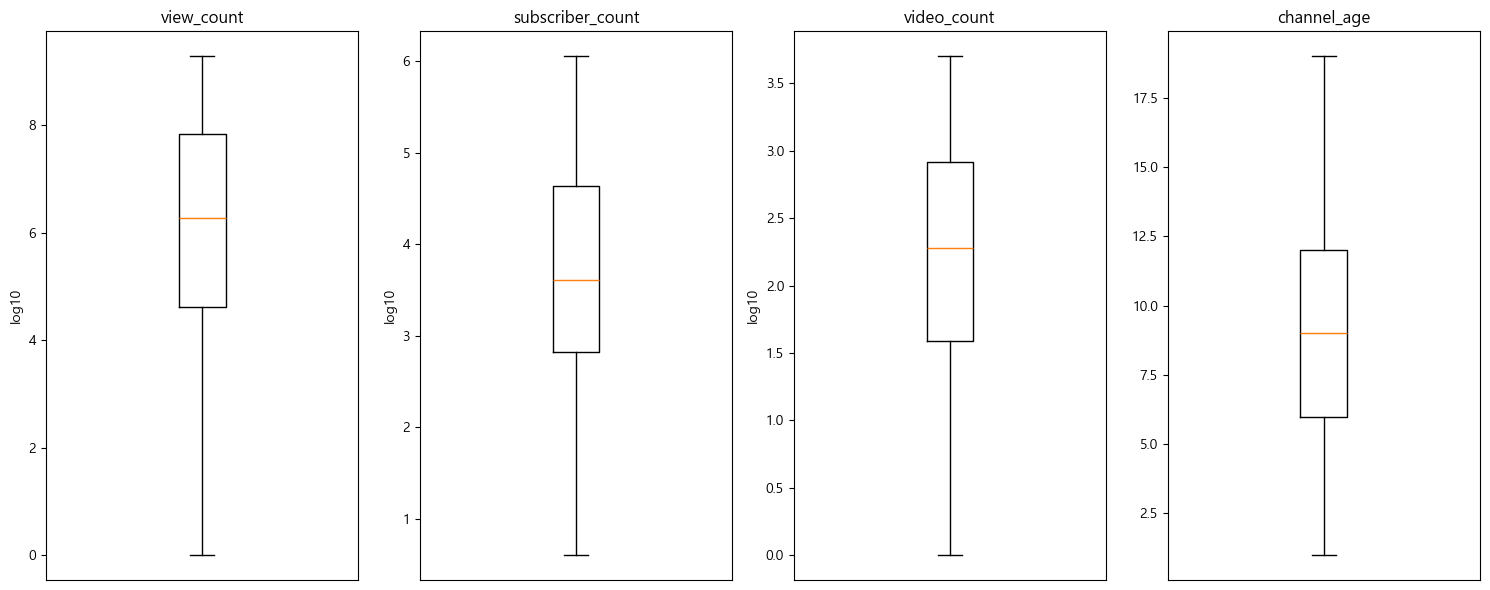

In [17]:
# 데이터 분포 확인 
# - view_count, subscriber_count, video_count
# - 극단값이 존재할 것으로 예상되어 로그 스케일로 변환하여 박스플롯으로 분포를 확인할 예정
# - 데이터에 log을 취할 때, 1을 더한 이유: 각 컬럼들의 평균/최솟값/최댓값을 확인했을 때, 최솟값이 0인 경우가 있었는데
#                                    수학적으로 log(0)은 존재하지 않기 때문에 에러가 생기지 않도록 1을 더한 것이다
#                                    숫자가 커질수록 +1의 영향은 매우 작기 때문에 가능하다.
fig, axes = plt.subplots(1, 4, figsize=(15, 6))

cols = ['view_count', 'subscriber_count', 'video_count']

for ax, col in zip(axes, cols): # zip()함수를 사용해서 인덱스 순서대로 axes[i]와 컬럼이 짝지어짐
    log_data_boxplot = np.log10(df_channel_IT_ststs[col] + 1) # 데이터에 로그를 취함
    ax.boxplot(log_data_boxplot)
    ax.set_title(col)
    ax.set_xticks([])       # x축 숫자 제거
    ax.set_ylabel('log10')  # y축 값이 log 10을 취한 값이라는 걸 나타내기 위해 추가

# channel_age - 스케일 변환 x
axes[3].boxplot(df_channel_IT_ststs['channel_age'])
axes[3].set_title('channel_age')
axes[3].set_xticks([])

plt.tight_layout()
plt.show()




# 숫자 단위 약어 해석
# K = 1,000
# M = 1,000,000 (백 만)
# B = 1,000,000,000 (십 억)

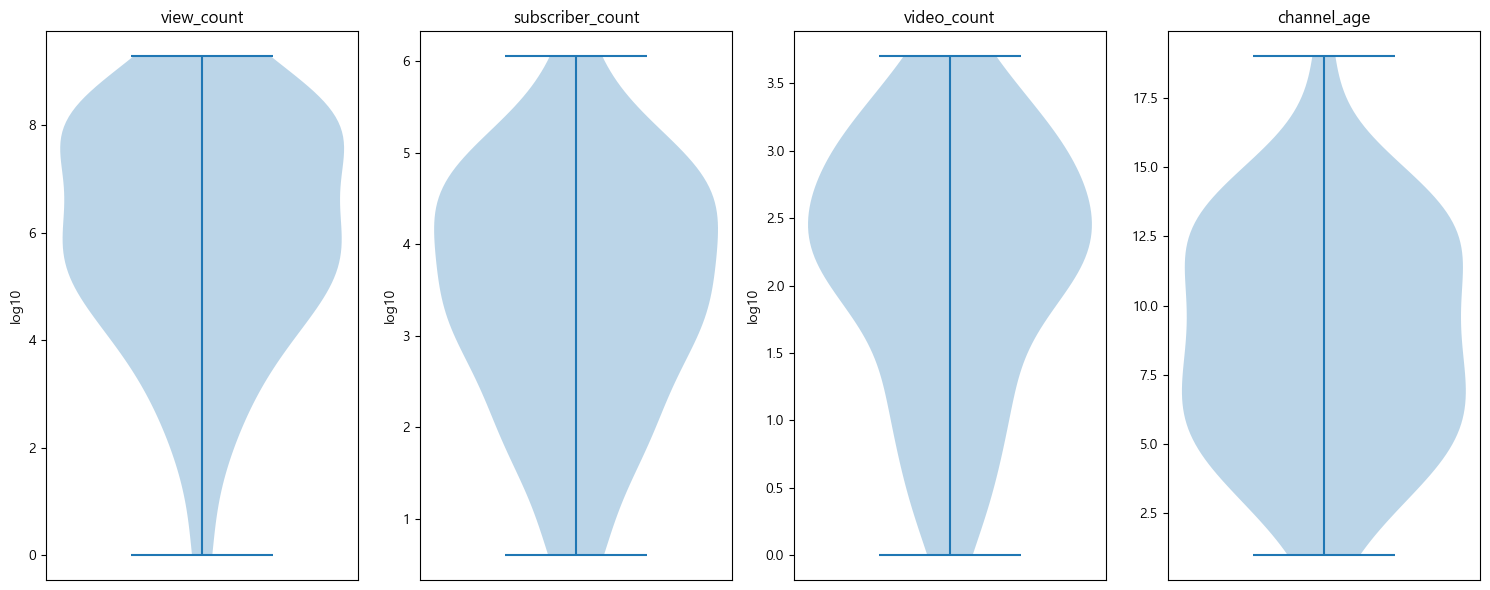

In [18]:
# 바이올린 플롯으로도 확인
fig, axes = plt.subplots(1, 4, figsize=(15, 6))

cols = ['view_count', 'subscriber_count', 'video_count']

for ax, col in zip(axes, cols):
    log_data_violinplot = np.log10(df_channel_IT_ststs[col] + 1)
    ax.violinplot(log_data_violinplot)
    ax.set_title(col)
    ax.set_xticks([])
    ax.set_ylabel('log10')

# channel_age - 스케일 변환 x
axes[3].violinplot(df_channel_IT_ststs['channel_age'])
axes[3].set_title('channel_age')
axes[3].set_xticks([])

plt.tight_layout()
plt.show()

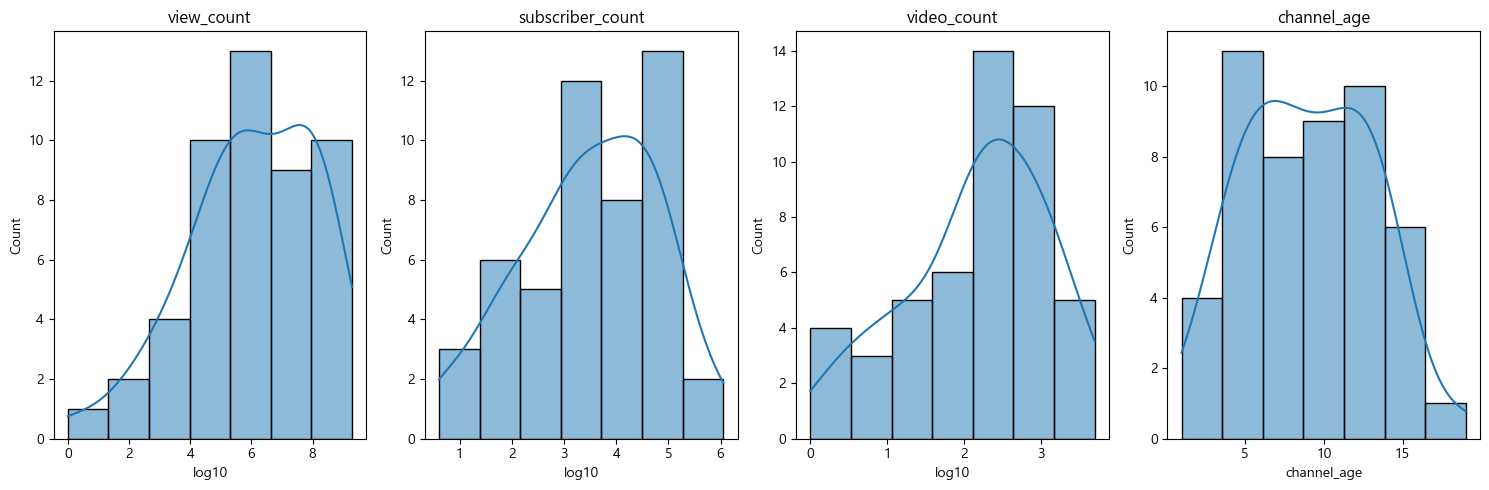

In [20]:
# 히스토그램과 KDE 곡선으로도 확인
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

cols = ['view_count', 'subscriber_count', 'video_count']

for ax, col in zip(axes, cols):
    log_data_hist = np.log10(df_channel_IT_ststs[col] + 1)
    sns.histplot(log_data_hist, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('log10')
    
sns.histplot(df_channel_IT_ststs['channel_age'], kde=True, ax=axes[3])
axes[3].set_title('channel_age')

plt.tight_layout()
plt.show()

---
### channel_age별 조회수, 구독자수, 비디오 개수 분포 확인하기

In [22]:
# 채널 연차별 기초 통계량
df_channel_IT_ststs.groupby('channel_age')[['view_count', 'subscriber_count', 'video_count']].describe()

view_count                                                        \
                 count          mean           std          min          25%   
channel_age                                                                    
1                  1.0  1.886434e+06           NaN    1886434.0    1886434.0   
2                  1.0  1.580000e+02           NaN        158.0        158.0   
3                  2.0  1.947040e+05  2.753021e+05         36.0      97370.0   
4                  3.0  3.228810e+05  3.709873e+05      34984.0     113549.5   
5                  5.0  5.685580e+04  1.208453e+05          0.0        522.0   
6                  3.0  1.892423e+05  2.560618e+05      41405.0      41405.0   
7                  5.0  1.011951e+06  1.565847e+06      25189.0     146591.0   
8                  3.0  2.823433e+04  3.598273e+04       5233.0       7501.0   
9                  3.0  2.292483e+07  1.794868e+07    2255388.0   17098730.5   
10                 5.0  1.117863e+08  1.225954e+08       1909.0     456306.0   
11                 1.0  2.027016e+06           NaN    2027016.0    2027016.0   
12                 6.0  4.155781e+07  6.926395e+07     196303.0    2807766.0   
13                 4.0  8.095669e+07  2.694811e+07   47538317.0   64946151.5   
14                 3.0  2.037467e+08  1.181617e+08   68717345.0  161511679.5   
15                 3.0  1.106340e+09  9.509783e+08   69696644.0  690345417.0   
19                 1.0  5.684888e+08           NaN  568488816.0  568488816.0   

                                                      subscriber_count  \
                      50%           75%           max            count   
channel_age                                                              
1            1.886434e+06  1.886434e+06  1.886434e+06              1.0   
2            1.580000e+02  1.580000e+02  1.580000e+02              1.0   
3            1.947040e+05  2.920380e+05  3.893720e+05              2.0   
4            1.921150e+05  4.668295e+05  7.415440e+05              3.0   
5            1.109000e+03  9.736000e+03  2.729120e+05              5.0   
6            4.140500e+04  2.631610e+05  4.849170e+05              3.0   
7            2.414870e+05  8.998010e+05  3.746685e+06              5.0   
8            9.769000e+03  3.973500e+04  6.970100e+04              3.0   
9            3.194207e+07  3.325956e+07  3.457704e+07              3.0   
10           7.469746e+07  2.418878e+08  2.418878e+08              5.0   
11           2.027016e+06  2.027016e+06  2.027016e+06              1.0   
12           9.256464e+06  4.154301e+07  1.776742e+08              6.0   
13           8.589427e+07  1.019048e+08  1.044999e+08              4.0   
14           2.543060e+08  2.712614e+08  2.882169e+08              3.0   
15           1.310994e+09  1.624662e+09  1.938330e+09              3.0   
19           5.684888e+08  5.684888e+08  5.684888e+08              1.0   

                                                                         \
                      mean            std      min        25%       50%   
channel_age                                                               
1             48500.000000            NaN  48500.0   48500.00   48500.0   
2                 3.000000            NaN      3.0       3.00       3.0   
3               742.500000    1042.982502      5.0     373.75     742.5   
4              1910.666667    2953.081498    151.0     206.00     261.0   
5               530.200000     659.051364      5.0      67.00      79.0   
6               869.333333     346.987512    669.0     669.00     669.0   
7              2873.600000    4137.752868    146.0     942.00    1340.0   
8                77.666667      32.624122     42.0      63.50      85.0   
9             30373.333333   34854.700305   6720.0   10360.00   14000.0   
10            29907.400000   22154.392878     37.0   12300.00   43200.0   
11             4080.000000            NaN   4080.0    4080.00    4080.0   
12            18271.666667   28588

In [26]:
# 숫자값만 바꾸면 해당 연차의 채널 확인 가능
df_channel_IT_ststs[df_channel_IT_ststs['channel_age'] == 3]

,channel_id,subscriber_count,view_count,video_count,created_date,channel_age
13,UCwfd3z7HQcVAbwPiZw6JNRw,5,36,2,2023-03-09 06:13:35.629477+00:00,3
20,UCmWvEmIve2QHxqgWXAblahA,1480,389372,190,2023-01-19 02:33:34.103290+00:00,3


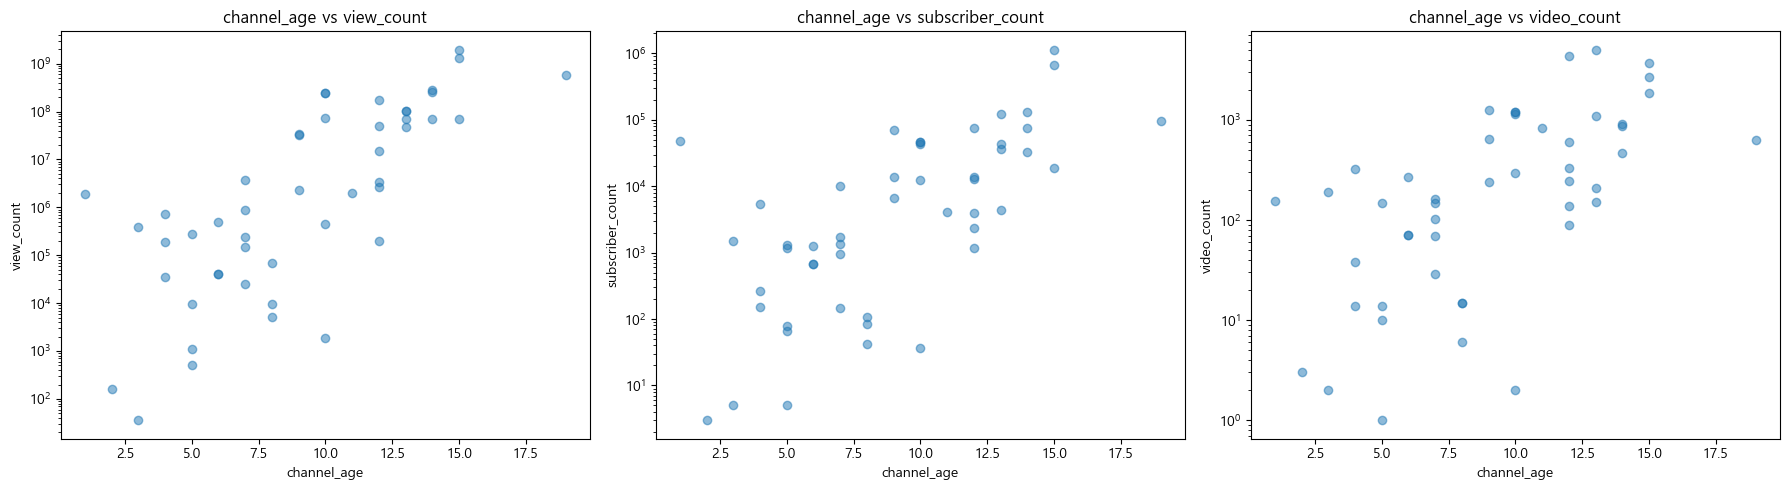

In [ ]:
# 채널 연차별 산점도
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cols = ['view_count', 'subscriber_count', 'video_count']

for ax, col in zip(axes, cols):
    ax.scatter(df_channel_IT_ststs['channel_age'], df_channel_IT_ststs[col], alpha=0.5)
    ax.set_yscale('log') # y축을 로그 스케일로 변경
    ax.set_xlabel('channel_age')
    ax.set_ylabel(col)
    ax.set_title(f'channel_age vs {col}')

plt.tight_layout()
plt.show()